<a href="https://colab.research.google.com/github/PRITHEW/DeepLearning_Class/blob/main/Convulutional_autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## OBjective
To build a Covolutional Autoencoder(CAE) that compresses facial images into a lower-dimensioal latent representation and reconstructs them with minimum loss of information

## Purpose
A convolutional Autoencoder is an unsupervised deep learning model used for:

Image Compression image Reconstruction Feature Extraction Dimensionality Reduction.

The encoder learns a compressed representation(latent space),while the decoder reconstructs the original image from this compressed representation.

In [39]:
# Libraries

import os # Provides functions for interacting with the operating system, like file paths and directories.
import shutil # Offers high-level file operations, such as copying and moving files.
import numpy as np # Fundamental package for scientific computing with Python, especially for arrays.
import matplotlib.pyplot as plt # A plotting library for creating static, interactive, and animated visualizations.

import tensorflow as tf # Google's open-source machine learning framework.

from tensorflow.keras.preprocessing.image import ImageDataGenerator # Utility for real-time data augmentation on image data.
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization, Dropout# Input: Defines the input shape; Conv2D: 2D Convolutional Layer for feature extraction; MaxPooling2D: Reduces spatial dimensions; UpSampling2D: Increases spatial dimensions.
from tensorflow.keras.models import Model # Used to define a Keras model.

In [40]:
#import dataset

import kagglehub

path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print(path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
/kaggle/input/celeba-dataset


In [41]:
#Create a smaller dataset (5000 images)
source_folder = os.path.join(path,"img_align_celeba", "img_align_celeba")

destination_folder = "celeba_small/faces"

os.makedirs(destination_folder, exist_ok=True)

images = sorted(os.listdir(source_folder))[:5000]

for img in images:
    shutil.copy(
        os.path.join(source_folder, img),
        destination_folder
    )
print("Copied",len(images),"images")

Copied 5000 images


In [42]:
#configure kaggle
# Create a .kaggle directory in the user's home directory if it doesn't exist
!mkdir -p ~/.kaggle
# Copy the kaggle.json file (which contains API credentials) to the .kaggle directory
!cp kaggle.json ~/.kaggle/
# Set appropriate permissions for the kaggle.json file (read/write for owner only) for security
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [43]:
# Data Preprocessing
# Define the target image dimensions (width, height) for resizing all input images.
IMAGE_SIZE =(64,64)
# Define the number of samples (images) to be processed in one batch during training/inference.
BATCH_SIZE =32

In [44]:
from IPython.utils.text import re # Imports the 're' module for regular expressions from IPython's utility library.
datagen=ImageDataGenerator(
    rescale=1./255, # Rescales pixel values from [0, 255] to [0, 1] for normalization.
    validation_split=0.2 # Reserves 20% of the images for validation.
)

In [45]:
# Load Dataset
train_generator=datagen.flow_from_directory(
    "celeba_small", # Specifies the directory containing the images for the generator.
    target_size=IMAGE_SIZE, # Resizes all images to the dimensions defined by IMAGE_SIZE (64x64).
    batch_size=BATCH_SIZE, # Sets the number of images to yield in each batch (32 images).
    class_mode="input", # For autoencoders, the input is also the target, so 'input' is used.
    subset="training" # Specifies that this generator should use the training subset of the data.
)

Found 4000 images belonging to 1 classes.


In [46]:
validation_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


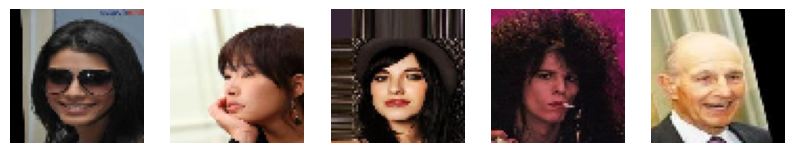

In [47]:
#Diaplay Sample Images
images,_ = next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()

In [48]:
# Build Convolutional Autoencoder
# Encoder

input_img = Input(shape=(64,64,3))   # <-- This line is required

x = Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)

x = BatchNormalization()(x)

x = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

x = Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)

x = BatchNormalization()(x)

encoded = MaxPooling2D(
    (2,2),
    padding='same'
)(x)

In [49]:
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = BatchNormalization()(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

In [50]:
#craete model
autoencoader=Model(
    input_img,
    decoded
)

In [51]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0005
)

autoencoader.compile(
    optimizer=optimizer,
    loss='mse'
)

In [52]:
#model summary
autoencoader.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,419 (298.51 KB)

 Trainable params: 76,035 (297.01 KB)

 Non-trainable params: 384 (1.50 KB)

In [53]:
#early stop
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

In [54]:
#ReduceLROnPlateau
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

In [55]:
#Tarin the model
history=autoencoader.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=25,
    callbacks=[
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True
    )
]

)

Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - loss: 0.0202 - val_loss: 0.0646
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0097 - val_loss: 0.0373
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0079 - val_loss: 0.0145
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0069 - val_loss: 0.0076
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0064 - val_loss: 0.0056
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0060 - val_loss: 0.0052
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0059 - val_loss: 0.0050
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.0055 - val_loss: 0.0047
Epoch 9/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0053 - val_loss: 0.0044
Epoch 10/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0049 - val_loss: 0.0043
Epoch 11/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0049 - val_loss: 0.0041
Epoch 12/25
125/125 ━━━━━━━━━━━━━━━━━━━━

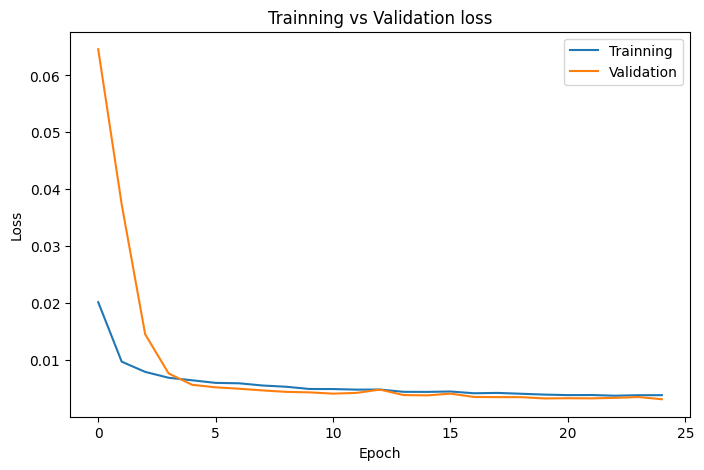

In [56]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Trainning vs Validation loss")
plt.legend(["Trainning",'Validation'])
plt.show()

In [57]:
#evaluate model
loss=autoencoader.evaluate(validation_generator)
print("validation loss:",loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0031
validation loss: 0.003107789671048522


In [58]:
#reconstruct Images
images,_=next(validation_generator)
reconstructed=autoencoader.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 909ms/step


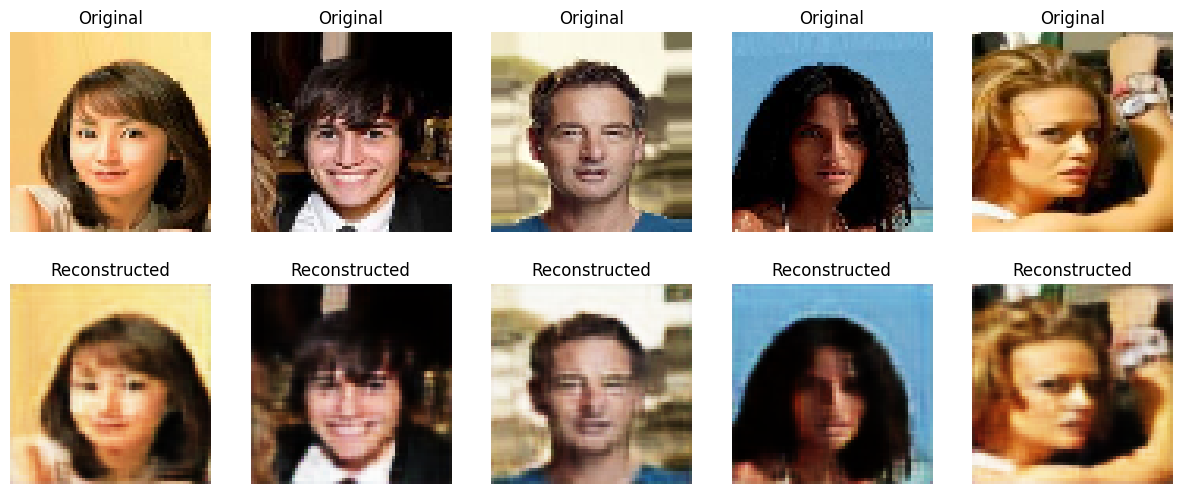

In [59]:
#display the results
n=5
plt.figure(figsize=(15,6))
for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.title("Original")
  plt.axis('off')
  plt.subplot(2,n,i+1+n)
  plt.imshow(reconstructed[i])
  plt.title("Reconstructed")
  plt.axis('off')
plt.show()


In [60]:
initial_val_loss = history.history['val_loss'][0]
final_val_loss = history.history['val_loss'][-1]

percentage_reduction = ((initial_val_loss - final_val_loss) / initial_val_loss) * 100

print(f"Validation Loss before fine-tuning (Epoch 1): {initial_val_loss:.4f}")
print(f"Validation Loss after fine-tuning (Final Epoch): {final_val_loss:.4f}")
print(f"Percentage reduction in Validation Loss: {percentage_reduction:.2f}%")

Validation Loss before fine-tuning (Epoch 1): 0.0646
Validation Loss after fine-tuning (Final Epoch): 0.0031
Percentage reduction in Validation Loss: 95.19%
